### BNS Jumping Test

In [69]:
from alpaca.data.historical import CryptoHistoricalDataClient

client = CryptoHistoricalDataClient()

from alpaca.data.requests import CryptoBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime

# Creating request object
request_params = CryptoBarsRequest(
  symbol_or_symbols=["BTC/USD"],
  timeframe=TimeFrame.Minute,
 #timeframe=TimeFrame.Day,
 #timeframe=TimeFrame.Hour,
  start=datetime(2022, 9, 1),
  end=datetime(2022, 9, 7)
)

# Retrieve daily bars for Bitcoin in a DataFrame and printing it
btc_bars = client.get_crypto_bars(request_params)

# Convert to dataframe
btc_bars.df


import numpy as np
import pandas as pd

# 1️⃣ 转换为 DataFrame 并处理索引
df = btc_bars.df.reset_index()
df = df[df["symbol"] == "BTC/USD"][["timestamp", "close"]]  # 保留收盘价与时间

# 2️⃣ 计算分钟级对数收益率
df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["date"] = df["timestamp"].dt.date
df = df.dropna()

# 3️⃣ BNS指标计算：按天计算 RV、BV、Jump Variation

# Realized Variance (RV)
daily_rv = df.groupby("date")["log_return"].apply(lambda r: np.sum(r ** 2))

# Bipower Variation (BV)
def compute_bv(returns):
    return (np.pi / 2) * np.sum(np.abs(returns[1:].values * returns[:-1].values))

daily_bv = df.groupby("date")["log_return"].apply(compute_bv)

# Jump Variation
jump_variation = daily_rv - daily_bv

# 可选：设置阈值判断是否显著跳跃
threshold = 1e-5
jump_flag = jump_variation > threshold

# 4️⃣ 合并输出表格
bns_df = pd.DataFrame({
    "RV": daily_rv,
    "BV": daily_bv,
    "Jump_Variation": jump_variation,
    "Jump_Flag": jump_flag
})

# 查看结果
print("📊 BNS 跳跃检测结果：")
print(bns_df)

# 保存为 CSV 文件
bns_df.to_csv("bns_jump_detection_BTCUSD.csv")

📊 BNS 跳跃检测结果：
                      RV        BV  Jump_Variation  Jump_Flag
date                                                         
2022-09-01  8.170142e-04  0.000770    4.663956e-05       True
2022-09-02  6.715961e-04  0.000652    1.941746e-05       True
2022-09-03  2.535721e-04  0.000227    2.646055e-05       True
2022-09-04  2.617056e-04  0.000258    4.084374e-06      False
2022-09-05  3.092369e-04  0.000291    1.811498e-05       True
2022-09-06  1.159685e-03  0.000935    2.251128e-04       True
2022-09-07  6.566132e-07  0.000000    6.566132e-07      False


### Algo Trading Benchmark

#### VWAP & TWAP

DataFrame Head:
    symbol                 timestamp      open      high       low     close  \
0  BTC/USD 2022-09-01 00:00:00+00:00  20051.81  20055.59  20023.52  20023.52   
1  BTC/USD 2022-09-01 00:01:00+00:00  20023.52  20035.29  20000.00  20035.29   
2  BTC/USD 2022-09-01 00:02:00+00:00  20031.38  20071.79  20020.00  20064.99   
3  BTC/USD 2022-09-01 00:03:00+00:00  20065.36  20107.23  20065.36  20103.30   
4  BTC/USD 2022-09-01 00:04:00+00:00  20107.23  20110.44  20082.00  20110.05   

      volume  trade_count          vwap          TWAP  Typical_Price  \
0   6.184083        123.0  20043.889989  20023.520000   20034.210000   
1   7.636889        106.0  20007.383661  20029.405000   20023.526667   
2  17.616520        187.0  20044.975294  20041.266667   20052.260000   
3   7.448067        140.0  20087.130855  20056.775000   20091.963333   
4   6.151111        107.0  20100.040740  20067.430000   20100.830000   

             TPV          VWAP  
0  123893.217479  20034.210000  
1  1

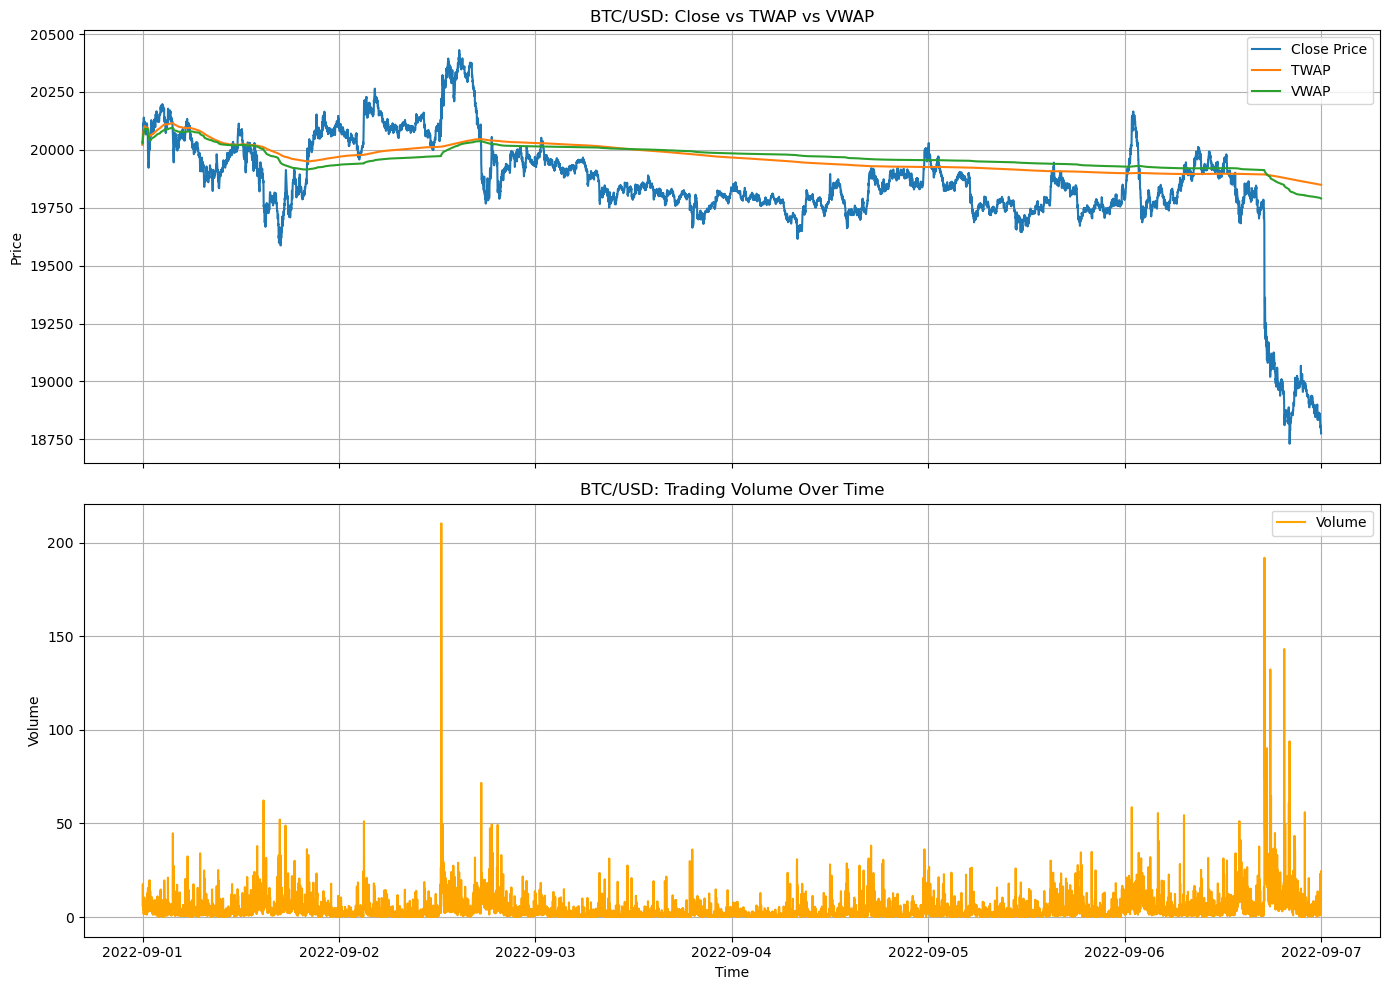

In [6]:
from alpaca.data.historical import CryptoHistoricalDataClient
from alpaca.data.requests import CryptoBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

# 初始化客户端
client = CryptoHistoricalDataClient()

# 设置请求参数：获取 1 分钟的 BTC/USD 数据
request_params = CryptoBarsRequest(
    symbol_or_symbols=["BTC/USD"],
    timeframe=TimeFrame.Minute,
    start=datetime(2022, 9, 1),
    end=datetime(2022, 9, 7)
)

# 获取数据
btc_bars = client.get_crypto_bars(request_params)

# 转换为 DataFrame
df = btc_bars.df.reset_index()

# 只保留 BTC/USD 数据
df = df[df['symbol'] == 'BTC/USD'].copy()

# 计算 TWAP：按时间平均 Close
df['TWAP'] = df['close'].expanding().mean()

# 计算 VWAP
df['Typical_Price'] = (df['high'] + df['low'] + df['close']) / 3
df['TPV'] = df['Typical_Price'] * df['volume']
df['VWAP'] = df['TPV'].cumsum() / df['volume'].cumsum()

# 打印 DataFrame 的头部
print("DataFrame Head:")
print(df.head())
print("\n")

# 绘制价格、TWAP 和 VWAP
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 第一个子图：价格 vs 时间
axs[0].plot(df['timestamp'], df['close'], label='Close Price')
axs[0].plot(df['timestamp'], df['TWAP'], label='TWAP')
axs[0].plot(df['timestamp'], df['VWAP'], label='VWAP')
axs[0].set_title('BTC/USD: Close vs TWAP vs VWAP')
axs[0].set_ylabel('Price')
axs[0].legend()
axs[0].grid(True)

# 第二个子图：交易量 vs 时间
axs[1].plot(df['timestamp'], df['volume'], color='orange', label='Volume')
axs[1].set_title('BTC/USD: Trading Volume Over Time')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Volume')
axs[1].legend()
axs[1].grid(True)

# 自动调整布局
plt.tight_layout()
plt.show()

🏁 Trading Competition Summary:
   Round  Best Price Maker       Cost  Cumulative Cost
0      1    19805.53  MM_2  1980553.0        1980553.0
1      2    19806.79  MM_1  1980679.0        3961232.0
2      3    19804.34  MM_3  1980434.0        5941666.0
3      4    19800.81  MM_6  1980081.0        7921747.0
4      5    19805.41  MM_6  1980541.0        9902288.0
5      6    19804.13  MM_6  1980413.0       11882701.0
6      7    19805.06  MM_2  1980506.0       13863207.0
7      8    19809.10  MM_3  1980910.0       15844117.0
8      9    19810.74  MM_1  1981074.0       17825191.0
9     10    19801.50  MM_3  1980150.0       19805341.0

✅ Final Average Execution Price: ¥19805.34


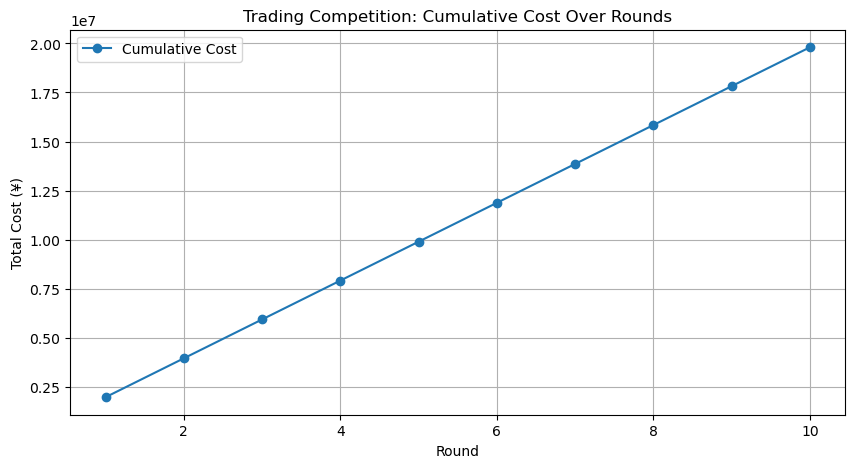

In [10]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# ==== 模拟做市商报价逻辑 ====
def simulate_market_makers(n_makers=5, base_price=20000, spread=50):
    makers = {}
    for i in range(n_makers):
        bid = base_price - random.uniform(0, spread)
        ask = base_price + random.uniform(0, spread)
        makers[f"MM_{i+1}"] = {"bid": round(bid, 2), "ask": round(ask, 2)}
    return makers

# ==== 自动选择最优报价并成交 ====
def auto_execute_rfq(makers, direction='buy'):
    if direction == 'buy':
        best_maker = min(makers.items(), key=lambda x: x[1]['ask'])
        return best_maker[1]['ask'], best_maker[0]
    else:
        best_maker = max(makers.items(), key=lambda x: x[1]['bid'])
        return best_maker[1]['bid'], best_maker[0]

# ==== 比赛模拟函数 ====
def simulate_trading_competition(rounds=10, unit_per_round=100, base_price=20000):
    total_cost = 0
    records = []

    for round_num in range(1, rounds + 1):
        makers = simulate_market_makers(n_makers=6, base_price=base_price)
        exec_price, maker = auto_execute_rfq(makers, direction='buy')
        cost = exec_price * unit_per_round
        total_cost += cost

        records.append({
            "Round": round_num,
            "Best Price": exec_price,
            "Maker": maker,
            "Cost": cost,
            "Cumulative Cost": total_cost
        })

    return pd.DataFrame(records)

# ==== 可视化累计成本变化 ====
def plot_cost_trend(df):
    plt.figure(figsize=(10, 5))
    plt.plot(df["Round"], df["Cumulative Cost"], marker='o', label='Cumulative Cost')
    plt.title("Trading Competition: Cumulative Cost Over Rounds")
    plt.xlabel("Round")
    plt.ylabel("Total Cost (¥)")
    plt.grid(True)
    plt.legend()
    plt.show()

# ==== 主程序 ====
if __name__ == "__main__":
    competition_df = simulate_trading_competition(rounds=10, unit_per_round=100, base_price=19800)
    print("🏁 Trading Competition Summary:")
    print(competition_df)

    avg_price = competition_df["Cost"].sum() / (100 * 10)
    print(f"\n✅ Final Average Execution Price: ¥{avg_price:.2f}")

    plot_cost_trend(competition_df)

##### 加入滑点后

DataFrame Head:
                  timestamp     close          TWAP          VWAP  \
0 2022-09-01 00:00:00+00:00  20023.52  20023.520000  20034.210000   
1 2022-09-01 00:01:00+00:00  20035.29  20029.405000  20028.306838   
2 2022-09-01 00:02:00+00:00  20064.99  20041.266667  20041.729390   
3 2022-09-01 00:03:00+00:00  20103.30  20056.775000  20051.351105   
4 2022-09-01 00:04:00+00:00  20110.05  20067.430000  20058.108935   

      TWAP_exec     VWAP_exec  
0  20033.531760  20044.227105  
1  20039.419702  20038.320992  
2  20051.287300  20051.750254  
3  20066.803388  20061.376781  
4  20077.463715  20068.137990  




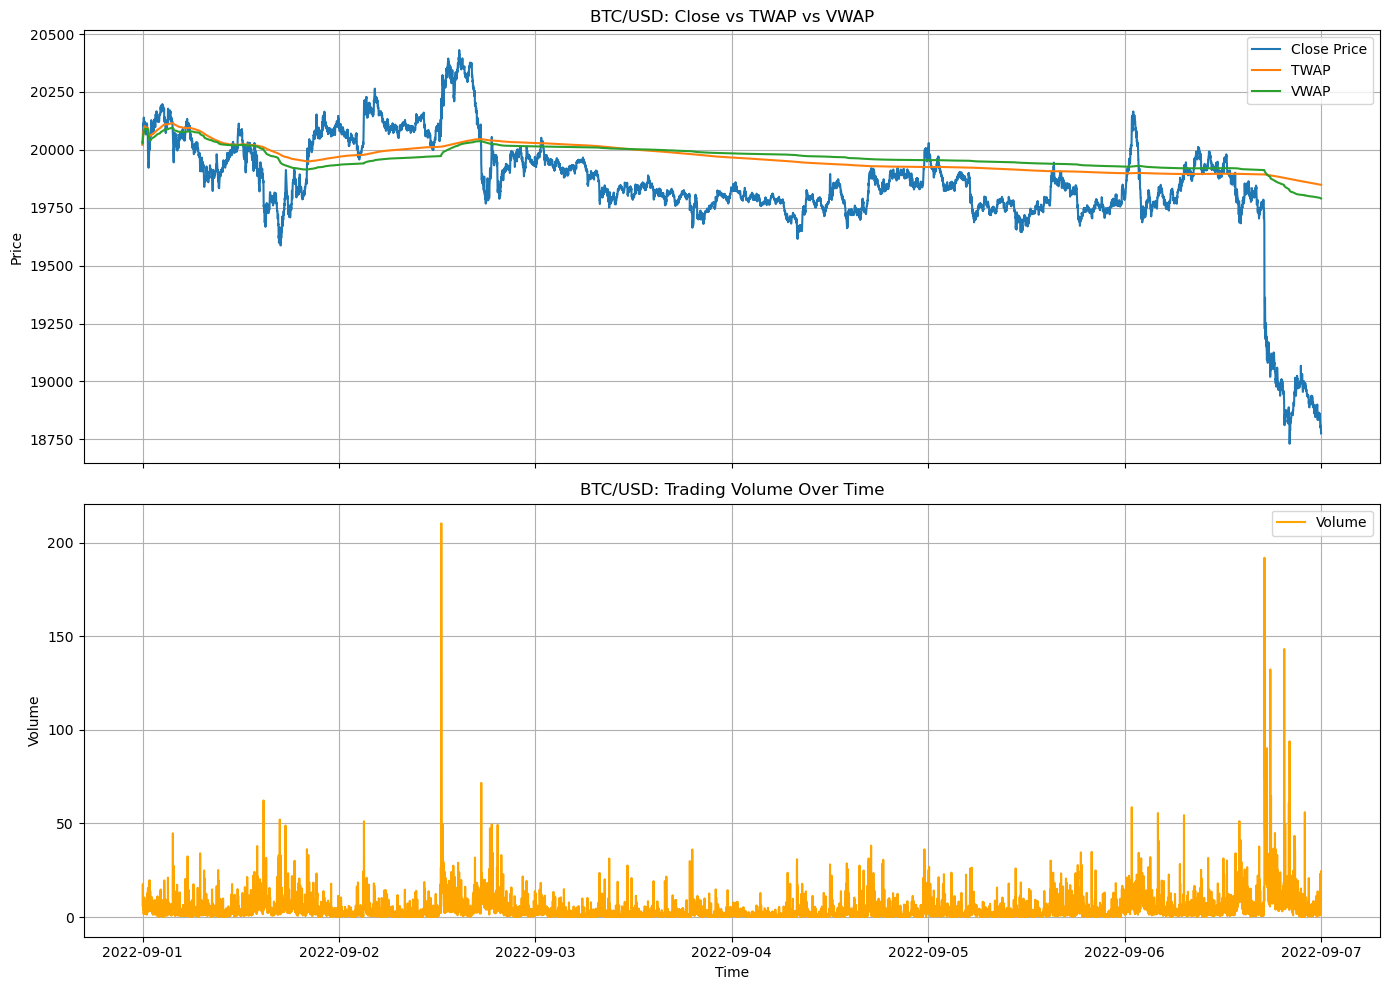

In [5]:
from alpaca.data.historical import CryptoHistoricalDataClient
from alpaca.data.requests import CryptoBarsRequest
from alpaca.data.timeframe import TimeFrame
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

# ==== 获取真实市场数据函数 ====
def fetch_btc_data(start_date, end_date):
    client = CryptoHistoricalDataClient()
    request_params = CryptoBarsRequest(
        symbol_or_symbols=["BTC/USD"],
        timeframe=TimeFrame.Minute,
        start=start_date,
        end=end_date
    )
    btc_bars = client.get_crypto_bars(request_params)
    df = btc_bars.df.reset_index()
    df = df[df['symbol'] == 'BTC/USD'].copy()
    return df

# ==== 计算 TWAP 和 VWAP ====
def compute_twap_vwap(df, slippage_bps=5):  # slippage in basis points (bps)
    df['TWAP'] = df['close'].expanding().mean()
    df['Typical_Price'] = (df['high'] + df['low'] + df['close']) / 3
    df['TPV'] = df['Typical_Price'] * df['volume']
    df['VWAP'] = df['TPV'].cumsum() / df['volume'].cumsum()

    # 模拟滑点：假设执行价格比市场价格差 slippage_bps 个基点（0.01%）
    slippage_pct = slippage_bps / 10000
    df['TWAP_exec'] = df['TWAP'] * (1 + slippage_pct)
    df['VWAP_exec'] = df['VWAP'] * (1 + slippage_pct)
    return df

# ==== 可视化函数 ====
def plot_price_volume(df):
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    axs[0].plot(df['timestamp'], df['close'], label='Close Price')
    axs[0].plot(df['timestamp'], df['TWAP'], label='TWAP')
    axs[0].plot(df['timestamp'], df['VWAP'], label='VWAP')
    axs[0].set_title('BTC/USD: Close vs TWAP vs VWAP')
    axs[0].set_ylabel('Price')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(df['timestamp'], df['volume'], color='orange', label='Volume')
    axs[1].set_title('BTC/USD: Trading Volume Over Time')
    axs[1].set_xlabel('Time')
    axs[1].set_ylabel('Volume')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# ==== 主程序入口 ====
if __name__ == '__main__':
    start_date = datetime(2022, 9, 1)
    end_date = datetime(2022, 9, 7)
    df = fetch_btc_data(start_date, end_date)
    df = compute_twap_vwap(df)

    print("DataFrame Head:")
    print(df[['timestamp', 'close', 'TWAP', 'VWAP', 'TWAP_exec', 'VWAP_exec']].head())
    print("\n")

    plot_price_volume(df)

